In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data-bank.csv')

In [2]:
print("Informasi Dataset:")
print(df.info())
print("\n5 Baris Pertama Data:")
print(df.head())

print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

print("\nDistribusi Target Variable (Bankrupt?):")
print(df['Bankrupt?'].value_counts())
print(f"Persentase Bank Bangkrut: {df['Bankrupt?'].value_counts()[1]/len(df)*100:.2f}%")
print(f"Persentase Bank Tidak Bangkrut: {df['Bankrupt?'].value_counts()[0]/len(df)*100:.2f}%")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8  

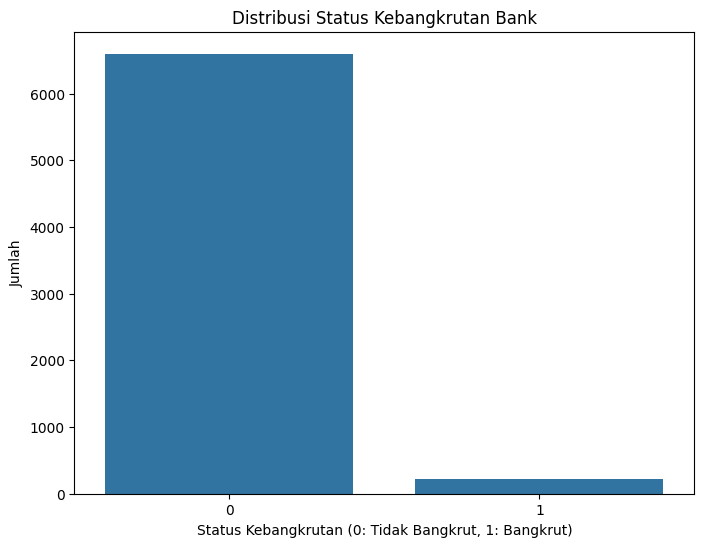

In [3]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Bankrupt?', data=df)
plt.title('Distribusi Status Kebangkrutan Bank')
plt.xlabel('Status Kebangkrutan (0: Tidak Bangkrut, 1: Bangkrut)')
plt.ylabel('Jumlah')
plt.show()

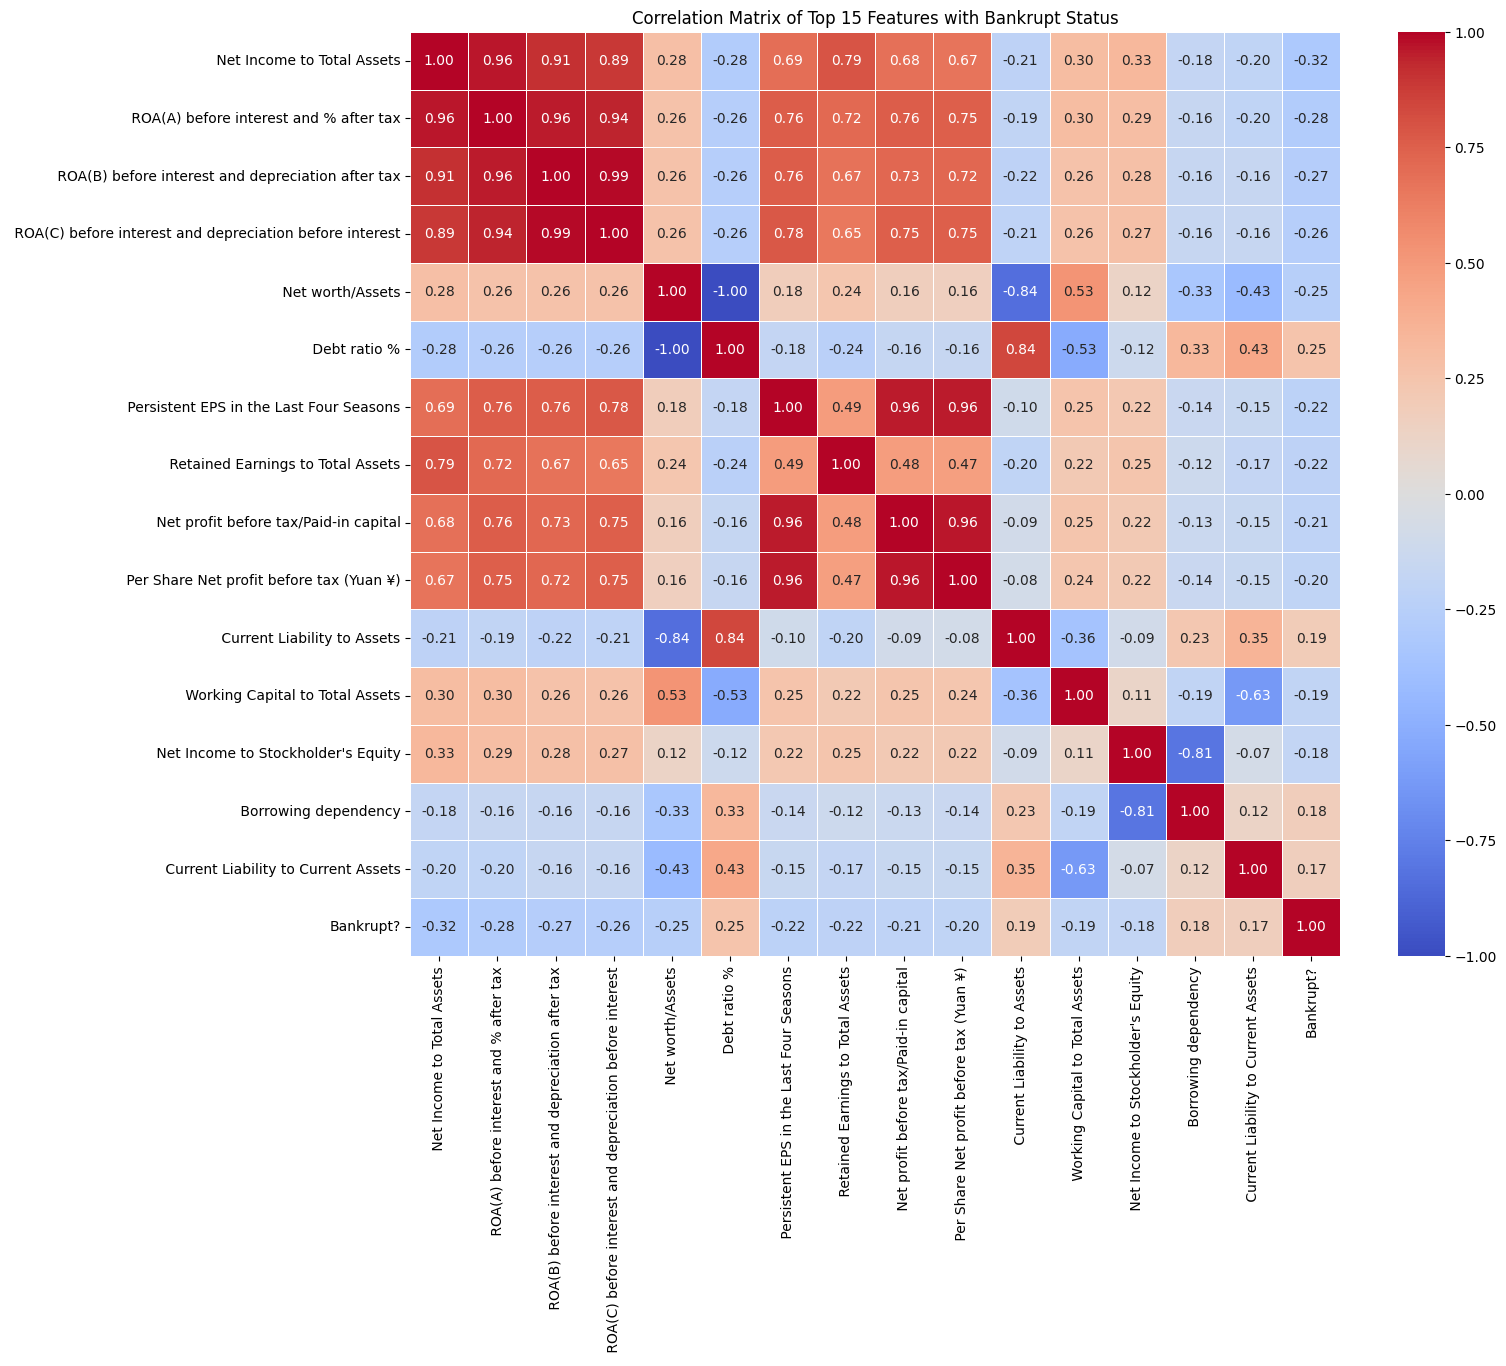

In [4]:
correlation_matrix = df.corr()
correlation_with_target = correlation_matrix['Bankrupt?'].abs().sort_values(ascending=False)
top_features = correlation_with_target.index[1:16] # Get top 15 features, excluding 'Bankrupt?' itself
selected_features = top_features.tolist() + ['Bankrupt?'] # Add 'Bankrupt?' back for the heatmap

correlation_matrix_subset = correlation_matrix.loc[selected_features, selected_features]

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix_subset, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Top 15 Features with Bankrupt Status')
plt.show()

In [5]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution after SMOTE:")
print(y_resampled.value_counts())

Class distribution after SMOTE:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [6]:
# Modelling: Random Forest (SMOTE)
smote = SMOTE(random_state=42)
scaler = StandardScaler()
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

pipe_rf = ImbPipeline(steps=[
    ('smote', smote),
    ('scaler', scaler),
    ('clf', rf)
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))


Random Forest classification report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.40      0.61      0.49        44

    accuracy                           0.96      1364
   macro avg       0.69      0.79      0.73      1364
weighted avg       0.97      0.96      0.96      1364

ROC AUC: 0.9363119834710744


In [7]:
# Decision Tree baseline
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=6)
pipe_dt = ImbPipeline([('smote', smote), ('scaler', scaler), ('clf', dt)])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)
y_proba_dt = pipe_dt.predict_proba(X_test)[:,1]

print("Decision Tree classification report:")
print(classification_report(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))


Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1320
           1       0.17      0.66      0.27        44

    accuracy                           0.89      1364
   macro avg       0.58      0.78      0.61      1364
weighted avg       0.96      0.89      0.92      1364

ROC AUC: 0.8491821625344353


In [8]:
# ANN  — resample train
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
sc_ann = StandardScaler()
X_train_res_s = sc_ann.fit_transform(X_train_res)
X_test_s = sc_ann.transform(X_test)

from tensorflow.keras import models, layers, callbacks

ann = models.Sequential([
    layers.Input(shape=(X_train_res_s.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ann.fit(X_train_res_s, y_train_res, validation_split=0.15, epochs=100, batch_size=32, callbacks=[es], verbose=1)

y_proba_ann = ann.predict(X_test_s).ravel()
y_pred_ann = (y_proba_ann > 0.5).astype(int)

print("ANN classification report:")
print(classification_report(y_test, y_pred_ann))
print("ROC AUC:", roc_auc_score(y_test, y_proba_ann))


Epoch 1/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.9523 - loss: 0.2778 - val_AUC: 0.0000e+00 - val_loss: 0.2669
Epoch 2/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9735 - loss: 0.2011 - val_AUC: 0.0000e+00 - val_loss: 0.1965
Epoch 3/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9803 - loss: 0.1689 - val_AUC: 0.0000e+00 - val_loss: 0.1219
Epoch 4/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9861 - loss: 0.1349 - val_AUC: 0.0000e+00 - val_loss: 0.1019
Epoch 5/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9893 - loss: 0.1159 - val_AUC: 0.0000e+00 - val_loss: 0.0569
Epoch 6/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9918 - loss: 0.0987 - val_AUC: 0.0000e+00 - val_loss: 0.0592
Epoch 7/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9928 - loss: 0.0876 - val_AUC: 0.0000e+00 - val_loss: 0.0605
Epoch 8/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9941 - loss: 0.0813 - val_AUC: 0.0000e+00 - val_loss: 0.0458
Epoch 9/100
281/

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.40      0.61      0.49        44

    accuracy                           0.96      1364
   macro avg       0.69      0.79      0.73      1364
weighted avg       0.97      0.96      0.96      1364

ROC AUC: 0.9363119834710744


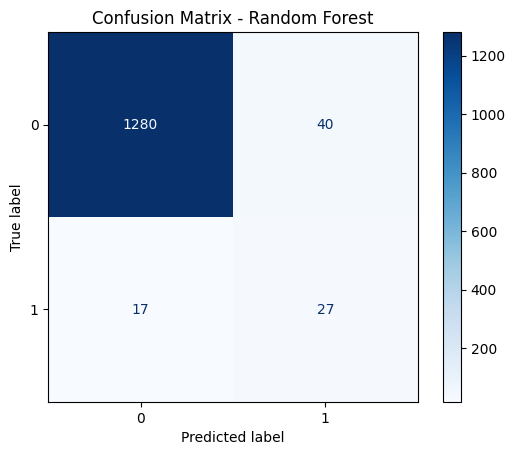

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1320
           1       0.17      0.66      0.27        44

    accuracy                           0.89      1364
   macro avg       0.58      0.78      0.61      1364
weighted avg       0.96      0.89      0.92      1364

ROC AUC: 0.8491821625344353


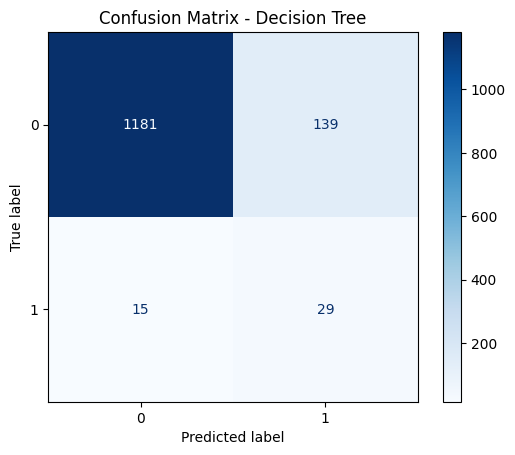

--- ANN ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.41      0.41      0.41        44

    accuracy                           0.96      1364
   macro avg       0.69      0.69      0.69      1364
weighted avg       0.96      0.96      0.96      1364

ROC AUC: 0.8542269283746556


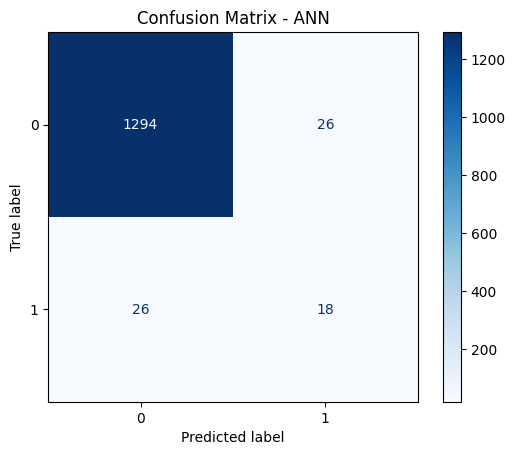

In [9]:
# Evaluation: Confusion Matrix & metrics helper
from sklearn.metrics import ConfusionMatrixDisplay

def eval_model(y_true, y_pred, y_proba, name):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

eval_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")
eval_model(y_test, y_pred_dt, y_proba_dt, "Decision Tree")
eval_model(y_test, y_pred_ann, y_proba_ann, "ANN")


Top 20 Feature Importance (RF):


,feature,importance
39,Borrowing dependency,0.058975
85,Net Income to Total Assets,0.057257
18,Persistent EPS in the Last Four Seasons,0.055960
7,After-tax net Interest Rate,0.052554
9,Continuous interest rate (after tax),0.043930
67,Retained Earnings to Total Assets,0.041218
37,Net worth/Assets,0.035631
90,Liability to Equity,0.034240
89,Net Income to Stockholder's Equity,0.030051
36,Debt ratio %,0.029900


SHAP Values shape: (1364, 95, 2)
X_test_scaled shape: (1364, 95)


<Figure size 1000x600 with 0 Axes>

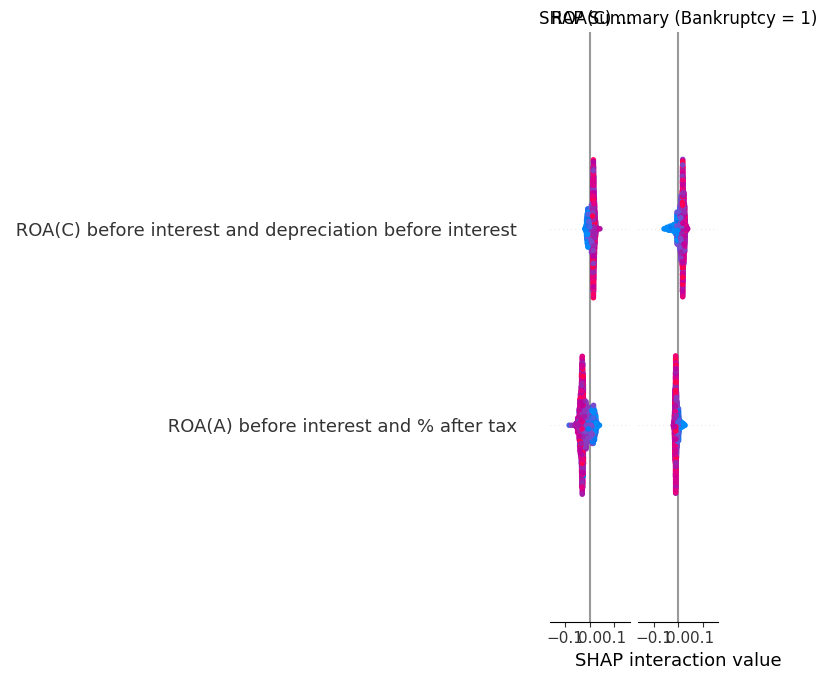


Top 5 Fitur berdasarkan SHAP:


,feature,mean_abs_shap
78,Equity to Long-term Liability,0.039816
79,Cash Flow to Total Assets,0.039816
18,Persistent EPS in the Last Four Seasons,0.029372
19,Cash Flow Per Share,0.029372
15,Net Value Per Share (B),0.027445


In [10]:
#  Explainability: Feature Importance + SHAP (Robust & Stable)


rf_model = pipe_rf.named_steps['clf']
feat_imp = rf_model.feature_importances_
feat_names = X_train.columns

feat_df = pd.DataFrame({'feature': feat_names, 'importance': feat_imp})
feat_df = feat_df.sort_values('importance', ascending=False)

print("Top 20 Feature Importance (RF):")
display(feat_df.head(20))


explainer = shap.TreeExplainer(rf_model)

X_test_scaled = pipe_rf.named_steps['scaler'].transform(X_test)
feature_names = X_test.columns.tolist()


shap_obj = explainer(X_test_scaled)

shap_arr = shap_obj.values

print("SHAP Values shape:", shap_arr.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


plt.figure(figsize=(10,6))
shap.summary_plot(shap_arr, X_test_scaled, feature_names=feature_names, show=False)
plt.title("SHAP Summary (Bankruptcy = 1)")
plt.show()


mean_abs_shap = np.mean(np.abs(shap_arr), axis=0)


mean_abs_shap = np.array(mean_abs_shap).ravel()


min_len = min(len(feature_names), len(mean_abs_shap))
feature_names = feature_names[:min_len]
mean_abs_shap = mean_abs_shap[:min_len]

imp_shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 5 Fitur berdasarkan SHAP:")
display(imp_shap_df.head(5))


In [11]:
top5_shap = imp_shap_df.head(5)

In [12]:
# Save models & SHAP results
joblib.dump(pipe_rf, 'models/rf_smote_pipeline.joblib')
ann.save('models/ann_model.h5')
imp_shap_df.head(50).to_csv('models/feature_shap_mean_abs.csv', index=False)
top5_shap.to_csv('models/top5_features_shap.csv', index=False)

print("Saved: rf_smote_pipeline.joblib, ann_model.h5, top5_features_shap.csv")


Saved: rf_smote_pipeline.joblib, ann_model.h5, top5_features_shap.csv
